# NB 1 — Veriyi Tanı (Data Understanding)

> **Yol Haritası adımları:** 1.1 → 1.2 → 1.3 → 1.4

---

## Bu notebook ne yapıyor?

Düşün ki sana 162 sütunlu, 30.000+ satırlık dev bir Excel dosyası verildi.
İlk sorun şu: **"Bu veride ne var? Hangi sütunlar işe yarar, hangileri boş?"**

Bu notebook tam olarak bunu cevaplayacak. Bir doktor yeni bir hastayı
incelediğinde önce genel muayene yapar — boy, kilo, kan basıncı. Biz de
verimize aynı şekilde bakıyoruz. Tek bir satır analiz yazmadan önce
**elimizde ne olduğunu** öğreneceğiz.

### Bu notebook'un çıktıları:
1. Her sütunun **boşluk yüzdesi** — bar grafik + `reports/null_summary.csv`
2. **%100 boş sütunların listesi** ve neden drop ettiğimiz
3. 6 anahtar kategorik sütunun **gerçek dağılımı** (sayısal kod → anlam)
4. Tarih sütunlarının **format teyidi** (DDMMYYYY olduğunu kanıtlayan örnekler)

---

### ⚠️ Şu an bilmen gereken en önemli şey

Bu verideki **"boş hücre"** her zaman "eksik veri" değil.
Örneğin: Bir hastanın `AdditionalDiagnosis2` sütunu boşsa,
bu "veri kaçırılmış" demek değil, "hastanın 2. ek tanısı yok" demek.
Bu farkı anlamadan boş hücreleri silersek verimizi mahvederiz.

**Kural:** Boş = "O olay yaşanmadı." Sil değil, anla.


## Başlangıç: Kütüphaneler ve veriyi yükle

Her notebook aynı şekilde başlar:
1. Kütüphaneleri import et
2. Proje kökünü bul (böylece dosya yolları makineden bağımsız olur)
3. Parquet'ten veri oku (NB0'da hazırladık, ~0.2 saniyede açılır)
4. Kod sözlüğünü yükle (NB0'da hazırladık, `reports/code_dictionary.json`)


In [1]:
import sys
from pathlib import Path
import json
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Grafik ayarları — tüm grafikler aynı stilde görünsün
plt.rcParams.update({
    "figure.dpi": 130,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})

# Proje kökü
NB_DIR       = Path.cwd()
PROJECT_ROOT = NB_DIR.parent if NB_DIR.name == "notebooks" else NB_DIR

PARQUET      = PROJECT_ROOT / "data" / "processed" / "hcp.parquet"
REPORTS_DIR  = PROJECT_ROOT / "reports"
FIGURES_DIR  = PROJECT_ROOT / "figures"

# Parquet'i oku — NB0'dan miras
df = pd.read_parquet(PARQUET)
print(f"✓ Veri yüklendi: {df.shape[0]:,} satır × {df.shape[1]} sütun")

# Kod sözlüğünü yükle
code_dict = json.loads((REPORTS_DIR / "code_dictionary.json").read_text())
print(f"✓ Kod sözlüğü yüklendi: {[k for k in code_dict if not k.startswith('_')]}")


✓ Veri yüklendi: 30,615 satır × 162 sütun
✓ Kod sözlüğü yüklendi: ['Sex', 'CareType', 'UrgencyOfAdmission', 'SameDayStatus', 'ModeOfSeparation', 'HospitalType']


## 1.1 — Verinin Genel Profili

### df.shape — "Bu tablonun boyutu nedir?"

`df.shape` sana (kaç satır, kaç sütun) ikisini verir.
Tıpkı "kaç sayfalık bir kitap bu?" diye sormak gibi.
Biz 30.615 hastanın 162 farklı özelliğine bakıyoruz.

---

### df.dtypes — "Her sütun hangi tip veri tutuyor?"

Sütunlar iki gruba ayrılıyor:

| Tip | Python adı | Örnek sütun | Ne demek? |
|-----|-----------|-------------|----------|
| Sayısal | `int64` | `ICU_Days`, `Sex` | Sayı (toplama, ortalama yapılabilir) |
| Metin/Karışık | `string` | `DRG`, `PrincipalDiagnosis` | Yazı ya da karışık içerik |

**Dikkat:** `Sex` sütunu `int64` — yani sayı. Ama `Sex=1` ile `Sex=2`'nin
**ortalamasını almak anlamsız** (`1.5 = yarı erkek yarı kadın` denilemez).
Bu sütun sayısal görünüyor ama aslında **kategori**. Bu tuzağa düşme.

---

### df.describe() — "Sayısal sütunların özet istatistikleri"

`describe()` her sayısal sütun için şunları verir:
- **count**: kaç değer var (boş olmayanlar)
- **mean**: ortalama
- **std**: standart sapma (ortalamadan ne kadar uzaklaşıyorlar)
- **min / max**: en küçük / en büyük
- **25% / 50% / 75%**: yüzdelikler (medyan = 50%)

Charge ve yatış süresi gibi sütunlar genellikle **sağa çarpık** dağılır:
birkaç çok pahalı vaka ortalamaı yukarı çeker, ama çoğu vaka ucuzdur.
Bu yüzden ortalama yerine **medyan (50%)** daha güvenilir bir merkez ölçüsüdür.


In [2]:
print("=" * 60)
print(f"SATIR SAYISI : {df.shape[0]:>10,}")
print(f"SÜTUN SAYISI : {df.shape[1]:>10,}")
print("=" * 60)

print("\nVERİ TİPİ DAĞILIMI:")
print(df.dtypes.value_counts().to_string())

print("\n" + "=" * 60)
print("SAYISAL SÜTUNLARIN ÖZET İSTATİSTİKLERİ")
print("(sadece anlamlı sayısal sütunlar — ID sütunları hariç)")
print("=" * 60)

# ID sütunlarını dışla, anlamlı sayısal sütunlara bak
exclude_id = ["EpisodeIdentifier", "InsurerIdentifier", "DateOfBirth",
              "AdmissionDate", "SeparationDate", "Postcode"]
numeric_cols = [c for c in df.select_dtypes("int64").columns
                if c not in exclude_id]

df[numeric_cols].describe().round(1)


SATIR SAYISI :     30,615
SÜTUN SAYISI :        162

VERİ TİPİ DAĞILIMI:
string[python]    117
int64              45

SAYISAL SÜTUNLARIN ÖZET İSTATİSTİKLERİ
(sadece anlamlı sayısal sütunlar — ID sütunları hariç)


,Sex,HospitalType,ICU_Days,ICU_Hours,TotalPyschCareDays,AdmissionTime,UrgencyOfAdmission,CareType,SourceOfReferral,InterHospitalContracted,...,BundledCharges,HIH_Charges,SCN_Charges,CCU_Charges,SCN_Hours,CCU_Hours,SCN_Days,CCU_Days,QualifiedDaysNewborns,PalliativeCareDays
count,30615.0,30615.0,30615.0,30615.0,30615.0,30615.0,30615.0,30615.0,30615.0,30615.0,...,30615.0,30615.0,30615.0,30615.0,30615.0,30615.0,30615.0,30615.0,30615.0,30615.0
mean,1.4,2.0,0.0,0.0,0.0,1073.2,2.0,1.1,7.5,8.7,...,167218.4,7.2,9.3,309.8,0.0,0.0,0.0,0.1,0.0,0.1
std,0.5,0.0,0.0,0.0,0.0,337.7,0.3,0.7,1.7,1.1,...,316807.3,782.6,1180.2,15065.0,0.0,1.2,0.0,0.4,0.1,1.3
min,1.0,2.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,5.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
25%,1.0,2.0,0.0,0.0,0.0,805.0,2.0,1.0,8.0,9.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
50%,1.0,2.0,0.0,0.0,0.0,1045.0,2.0,1.0,8.0,9.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
75%,2.0,2.0,0.0,0.0,0.0,1315.0,2.0,1.0,8.0,9.0,...,199200.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
max,2.0,2.0,0.0,0.0,0.0,2359.0,3.0,7.0,9.0,9.0,...,5707700.0,109800.0,174200.0,1481400.0,0.0,114.0,3.0,17.0,11.0,69.0


### Her sütun için hızlı bir "kimlik kartı"

Aşağıdaki kod her sütun için şunları listeler:
- **Veri tipi** (int64 mı, string mi?)
- **Benzersiz değer sayısı** (kaç farklı değer var?)
- **Boşluk yüzdesi** (ne kadarı dolu?)
- **İlk 3 örnek değer** (gerçekte ne görünüyor?)

Bu "kimlik kartı" hem NB2'deki temizlik kararları için hem de
sunumda "veriyi ne kadar iyi tanıdın?" sorusunun cevabı.


In [3]:
rows = []
NULL_LIKE = {"", "nan", "none", "na", "<na>", "nat", "null"}
for col in df.columns:
    s = df[col]
    # Boşluk tespiti: astype(str) → strip → lower → null-like set
    null_mask = s.astype(str).str.strip().str.lower().isin(NULL_LIKE)
    pct_null  = null_mask.mean() * 100
    n_unique  = s[~null_mask].astype(str).str.strip().nunique()
    samples   = (s[~null_mask].astype(str).str.strip()
                  .head(3).tolist())
    rows.append({
        "Sütun":    col,
        "Tip":      str(s.dtype),
        "Benzersiz": n_unique,
        "Boşluk %": round(pct_null, 1),
        "Örnekler": " | ".join(samples[:3]),
    })

col_profile = pd.DataFrame(rows)
print(f"Toplam {len(col_profile)} sütun profillendi.")
print("\nİlk 20 sütun:")
col_profile.head(20).to_string(index=False)


Toplam 162 sütun profillendi.

İlk 20 sütun:


'                   Sütun    Tip  Benzersiz  Boşluk %                       Örnekler\n       InsurerIdentifier string         10      46.8             INS1 | INS5 | INS9\n       EpisodeIdentifier  int64      30615       0.0    1624122 | 1624177 | 1624113\n             DateOfBirth  int64        105       0.0    1012000 | 1011937 | 1011968\n                Postcode  int64        223       0.0             6280 | 6233 | 6225\n                     Sex  int64          2       0.0                      1 | 2 | 2\n           AdmissionDate  int64        378       0.0    1012023 | 1012023 | 1012023\n          SeparationDate  int64        365       0.0    2012023 | 6012023 | 9012023\n            HospitalType  int64          1       0.0                      2 | 2 | 2\n                ICU_Days  int64          1       0.0                      0 | 0 | 0\n               ICU_Hours  int64          1       0.0                      0 | 0 | 0\n      TotalPyschCareDays  int64          1       0.0            

## 1.2 — Boşluk Haritası (Missing Value Map)

### "Boşluk haritası" nedir?

Her sütunun **ne kadarının dolu, ne kadarının boş** olduğunu gösteren bir
özet. Bunu bir sınıf defteri gibi düşün: her sütun bir öğrenci, her satır
bir sınav. "Bu öğrenci sınavların yüzde kaçına girdi?" sorusunun cevabı.

### 4 gruba ayırıyoruz:

| Grup | Boşluk % | Anlamı | Kararımız |
|------|----------|--------|-----------|
| 🟢 Neredeyse Tam | %0–5 | Güvenilir veri | Kullan |
| 🟡 Kısmen Dolu | %5–50 | Dikkatli kullan | Analiz et |
| 🟠 Çoğunlukla Boş | %50–99 | İnce eleyip sık dokuyarak kullan | Değerlendir |
| 🔴 Tamamen Boş | %100 | Bu veri kesitinde hiç kullanılmamış | **Drop et** |

### Neden bu grafiği yapıyoruz?

162 sütuna tek tek bakmak için 162 kez kod çalıştırmak zorunda değiliz.
Bu grafik bize 5 saniyede tüm resmi gösteriyor.


In [4]:
# Her sütunun boşluk yüzdesini hesapla
def null_pct(series: pd.Series) -> float:
    """
    HCP verisinde "boşluk" iki farklı şekilde gelir:
    1) pd.NA  → pandas'ın "bilgi yok" değeri (sayısal sütunlarda)
    2) "      " → boş hücre Excel'den whitespace (boşluk) string olarak gelmiş

    İkisini de yakalamak için her şeyi str'e çevirip temizliyoruz.
    Null-benzeri değerlerin tam listesi: "", "nan", "none", "na", "<na>", "nat"
    """
    s = series.astype(str).str.strip().str.lower()
    null_like = {"", "nan", "none", "na", "<na>", "nat", "null"}
    return s.isin(null_like).mean() * 100

null_df = pd.DataFrame({
    "column": df.columns,
    "null_pct": [null_pct(df[c]) for c in df.columns],
})
null_df = null_df.sort_values("null_pct", ascending=False).reset_index(drop=True)

# 4 gruba ayır
def group_label(pct: float) -> str:
    if pct == 100: return "🔴 %100 Boş (drop)"
    if pct >= 50:  return "🟠 %50–99 Boş"
    if pct > 5:    return "🟡 %5–50 Boş"
    return "🟢 %0–5 (Neredeyse Tam)"

null_df["group"] = null_df["null_pct"].apply(group_label)

print("BOŞLUK GRUPLARI ÖZET:")
print(null_df["group"].value_counts().sort_index().to_string())
print(f"\nToplam sütun: {len(null_df)}")


BOŞLUK GRUPLARI ÖZET:
group
🔴 %100 Boş (drop)         27
🟠 %50–99 Boş              84
🟡 %5–50 Boş                3
🟢 %0–5 (Neredeyse Tam)    48

Toplam sütun: 162


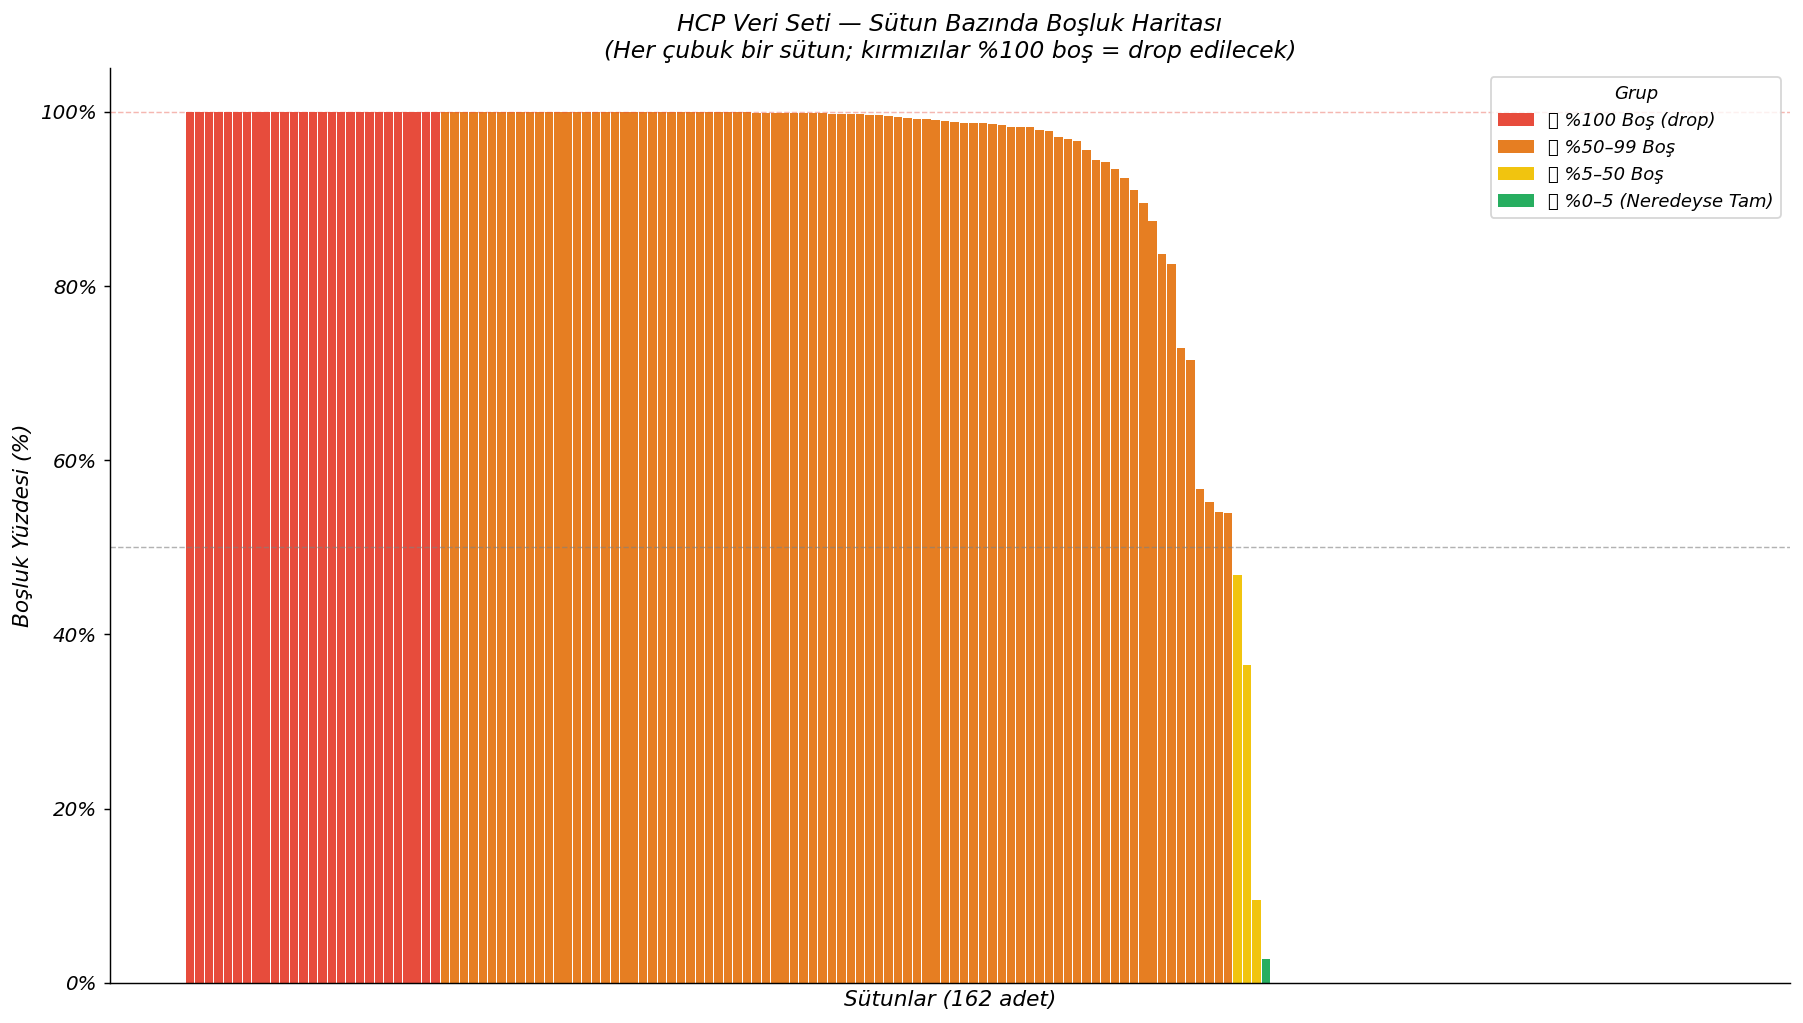

✓ Kaydedildi: figures/01_null_map.png


In [5]:
# BOŞLUK HARİTASI GRAFİĞİ
# Her çubuğu boşluk yüzdesine göre renklendiriyoruz.

colors = {
    "🔴 %100 Boş (drop)": "#e74c3c",
    "🟠 %50–99 Boş":       "#e67e22",
    "🟡 %5–50 Boş":        "#f1c40f",
    "🟢 %0–5 (Neredeyse Tam)": "#27ae60",
}

fig, ax = plt.subplots(figsize=(14, 8))

for _, row in null_df.iterrows():
    ax.bar(row["column"], row["null_pct"],
           color=colors[row["group"]], edgecolor="none", width=0.9)

ax.set_xlabel("Sütunlar (162 adet)", fontsize=12)
ax.set_ylabel("Boşluk Yüzdesi (%)", fontsize=12)
ax.set_title(
    "HCP Veri Seti — Sütun Bazında Boşluk Haritası\n"
    "(Her çubuk bir sütun; kırmızılar %100 boş = drop edilecek)",
    fontsize=13, fontweight="bold"
)
ax.set_xticks([])          # 162 sütun ismi sığmaz
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.axhline(50, color="gray", ls="--", lw=0.8, alpha=0.6)
ax.axhline(100, color="#e74c3c", ls="--", lw=0.8, alpha=0.4)

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=v, label=k) for k, v in colors.items()]
ax.legend(handles=legend_elements, loc="upper right", fontsize=10,
          title="Grup", title_fontsize=10)

plt.tight_layout()
fig.savefig(FIGURES_DIR / "01_null_map.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Kaydedildi: figures/01_null_map.png")


In [6]:
# Özet tabloyu diske kaydet — sunum için kullanacağız
null_df.to_csv(REPORTS_DIR / "null_summary.csv", index=False)
print("✓ Kaydedildi: reports/null_summary.csv")

# Gruplara göre özet
print("\nHer gruptaki sütun sayısı:")
for grp, cnt in null_df["group"].value_counts().items():
    cols_in_grp = null_df[null_df["group"] == grp]["column"].tolist()
    print(f"  {grp}: {cnt} sütun")
    if cnt <= 10:
        for c in cols_in_grp:
            print(f"      - {c}")
    else:
        print(f"      (ilk 5): {cols_in_grp[:5]}")


✓ Kaydedildi: reports/null_summary.csv

Her gruptaki sütun sayısı:
  🟠 %50–99 Boş: 84 sütun
      (ilk 5): ['Procedure32', 'Procedure31', 'Procedure26', 'Procedure30', 'Procedure27']
  🟢 %0–5 (Neredeyse Tam): 48 sütun
      (ilk 5): ['Procedure1', 'ProsthesisCharge', 'SeparationDate', 'AdmissionDate', 'Sex']
  🔴 %100 Boş (drop): 27 sütun
      (ilk 5): ['AdditionalDiagnosis49', 'Procedure33', 'Procedure35', 'Procedure36', 'Procedure37']
  🟡 %5–50 Boş: 3 sütun
      - InsurerIdentifier
      - AdditionalDiagnosis1
      - DischargeIntention


## 1.3 — %100 Boş Sütunları Çıkar (Drop)

### Neden bu sütunlar boş?

Bu HCP veri setinde bazı sütunlar **hiç kullanılmamış** — ya bu hastane
grubunda o özellik yoktu, ya da 2022-23 döneminde o alan henüz zorunlu
değildi. Bunlara örnek:

- `DRG_Version` — bu veri setinde tek bir DRG versiyonu kullanılmış
- `AdditionalDiagnosis23` ile `AdditionalDiagnosis49` arası — kimsenin
  23'ten fazla ek tanısı olmamış
- `Procedure26` ile `Procedure50` arası — benzer şekilde

### "Drop etmek" ne demek?

Drop = sütunu kalıcı olarak silmek. Ama dikkat: biz parquet'i
**değiştirmiyoruz**, sadece bu oturumda bellekteki `df`'i küçültüyoruz.
NB2'de temizlenmiş veriyi yeni bir parquet olarak kaydedeceğiz.

### Neden drop ediyoruz?

162 sütun yerine ~98 sütunla çalışmak:
- Daha hızlı kod
- Daha az "gürültü" (anlamsız sütun modeli kötüleştirir)
- Daha net analiz

Bunları **silmeden önce** listeliyoruz — sunumda "X sütun çünkü %100 boş
olduğu için çıkarıldı" demek disiplin göstergesidir.


In [7]:
# %100 boş sütunlar
cols_100_null = null_df[null_df["null_pct"] == 100.0]["column"].tolist()
print(f"Drop edilecek sütun sayısı: {len(cols_100_null)}")
print("\nListesi:")
for i, c in enumerate(sorted(cols_100_null), 1):
    print(f"  {i:3d}. {c}")


Drop edilecek sütun sayısı: 27

Listesi:
    1. AdditionalDiagnosis42
    2. AdditionalDiagnosis43
    3. AdditionalDiagnosis44
    4. AdditionalDiagnosis45
    5. AdditionalDiagnosis46
    6. AdditionalDiagnosis47
    7. AdditionalDiagnosis48
    8. AdditionalDiagnosis49
    9. DRG_Version
   10. Procedure33
   11. Procedure34
   12. Procedure35
   13. Procedure36
   14. Procedure37
   15. Procedure38
   16. Procedure39
   17. Procedure40
   18. Procedure41
   19. Procedure42
   20. Procedure43
   21. Procedure44
   22. Procedure45
   23. Procedure46
   24. Procedure47
   25. Procedure48
   26. Procedure49
   27. Procedure50


In [8]:
# Drop et
df_clean = df.drop(columns=cols_100_null)

print(f"ÖNCESİ: {df.shape[0]:,} satır × {df.shape[1]} sütun")
print(f"SONRASI: {df_clean.shape[0]:,} satır × {df_clean.shape[1]} sütun")
print(f"Çıkarılan: {df.shape[1] - df_clean.shape[1]} sütun")
print(f"\nKalan sütun tipi dağılımı:")
print(df_clean.dtypes.value_counts().to_string())


ÖNCESİ: 30,615 satır × 162 sütun
SONRASI: 30,615 satır × 135 sütun
Çıkarılan: 27 sütun

Kalan sütun tipi dağılımı:
string[python]    90
int64             45


### Kalan sütunlara hızlı bir bakış

Drop işleminden sonra kalan ~98 sütunun hangi kategorilere girdiğini
**kendi kafamıza göre** gruplandıralım. Bu gruplama NB2 ve NB3'teki
feature engineering için yol haritası olacak.


In [9]:
# Kalan sütunları tematik gruplara ayır
groups = {
    "🔷 Kimlik & İdari": [
        "InsurerIdentifier","EpisodeIdentifier","Postcode","HospitalType"
    ],
    "📅 Tarihler": [
        "DateOfBirth","AdmissionDate","SeparationDate","AdmissionTime"
    ],
    "🧑 Demografik": [
        "Sex","UrgencyOfAdmission","SameDayStatus","CareType",
        "DischargeIntention","ModeOfSeparation",
    ],
    "🏥 Klinik — Tanı & Prosedür": (
        [c for c in df_clean.columns if "Diagnosis" in c]
        + [c for c in df_clean.columns if "Procedure" in c or "MBS" in c]
    ),
    "💰 Ücret (Charge)": [
        c for c in df_clean.columns
        if c.endswith("Charge") or c.endswith("Charges")
    ],
    "🏨 Yoğun Bakım & Özel Birimler": [
        c for c in df_clean.columns
        if any(x in c for x in ["ICU","SCN","CCU","MechVent","Psych"])
    ],
    "🔢 DRG / MDC": [
        c for c in df_clean.columns
        if c.startswith("DRG") or c.startswith("MDC")
    ],
}

print(f"{'Grup':45s}  Sütun Sayısı")
print("-" * 60)
covered = set()
for grp_name, grp_cols in groups.items():
    valid_cols = [c for c in grp_cols if c in df_clean.columns]
    covered.update(valid_cols)
    print(f"  {grp_name:43s}  {len(valid_cols):>4}")

other = [c for c in df_clean.columns if c not in covered]
print(f"  {'📦 Diğer':43s}  {len(other):>4}")
print("-" * 60)
print(f"  {'TOPLAM':43s}  {df_clean.shape[1]:>4}")


Grup                                           Sütun Sayısı
------------------------------------------------------------
  🔷 Kimlik & İdari                                4
  📅 Tarihler                                      4
  🧑 Demografik                                    6
  🏥 Klinik — Tanı & Prosedür                     85
  💰 Ücret (Charge)                               11
  🏨 Yoğun Bakım & Özel Birimler                  10
  🔢 DRG / MDC                                     1
  📦 Diğer                                        17
------------------------------------------------------------
  TOPLAM                                        135


## 1.4 — Anahtar Kategorik Sütunların Dağılımı

### "Kategorik sütun" nedir?

Bazı sütunlar sayı gibi görünse de aslında **etiket** içerir.
Örneğin `Sex = 1` veya `Sex = 2` — bunlar sayı değil, **grup ismi**.

Biz NB0'da bunların çeviri tablosunu `code_dictionary.json`'a kaydetmiştik.
Şimdi bu sözlüğü kullanarak sayıları gerçek anlamlarıyla göstereceğiz.

### Neden bu 6 sütuna odaklanıyoruz?

Bu 6 sütun hem EDA'da (grafik analizinde) hem modelde sıklıkla kullanılacak
**segmentasyon değişkenleri**:

| Sütun | Sorusu |
|-------|--------|
| `Sex` | Cinsiyet dağılımı nasıl? |
| `CareType` | Hastalar en çok hangi bakım türünde? |
| `UrgencyOfAdmission` | Acil mi elektif mi daha fazla? |
| `SameDayStatus` | Günübirlik mi yatışlı mi? |
| `ModeOfSeparation` | Hastaneden nasıl ayrıldılar? |
| `HospitalType` | Hangi hastane türü ağırlıklı? |

### "9 kodu" tuzağına dikkat!

Roadmap'in kritik uyarısı: `9` kodunun anlamı çoğu sütunda
**"bilinmiyor / uygulanamaz"** demek. Bu bir sayı değil. Bu yüzden
`Sex` sütununun ortalamasını almamalıyız — `9` orada anomalidir.


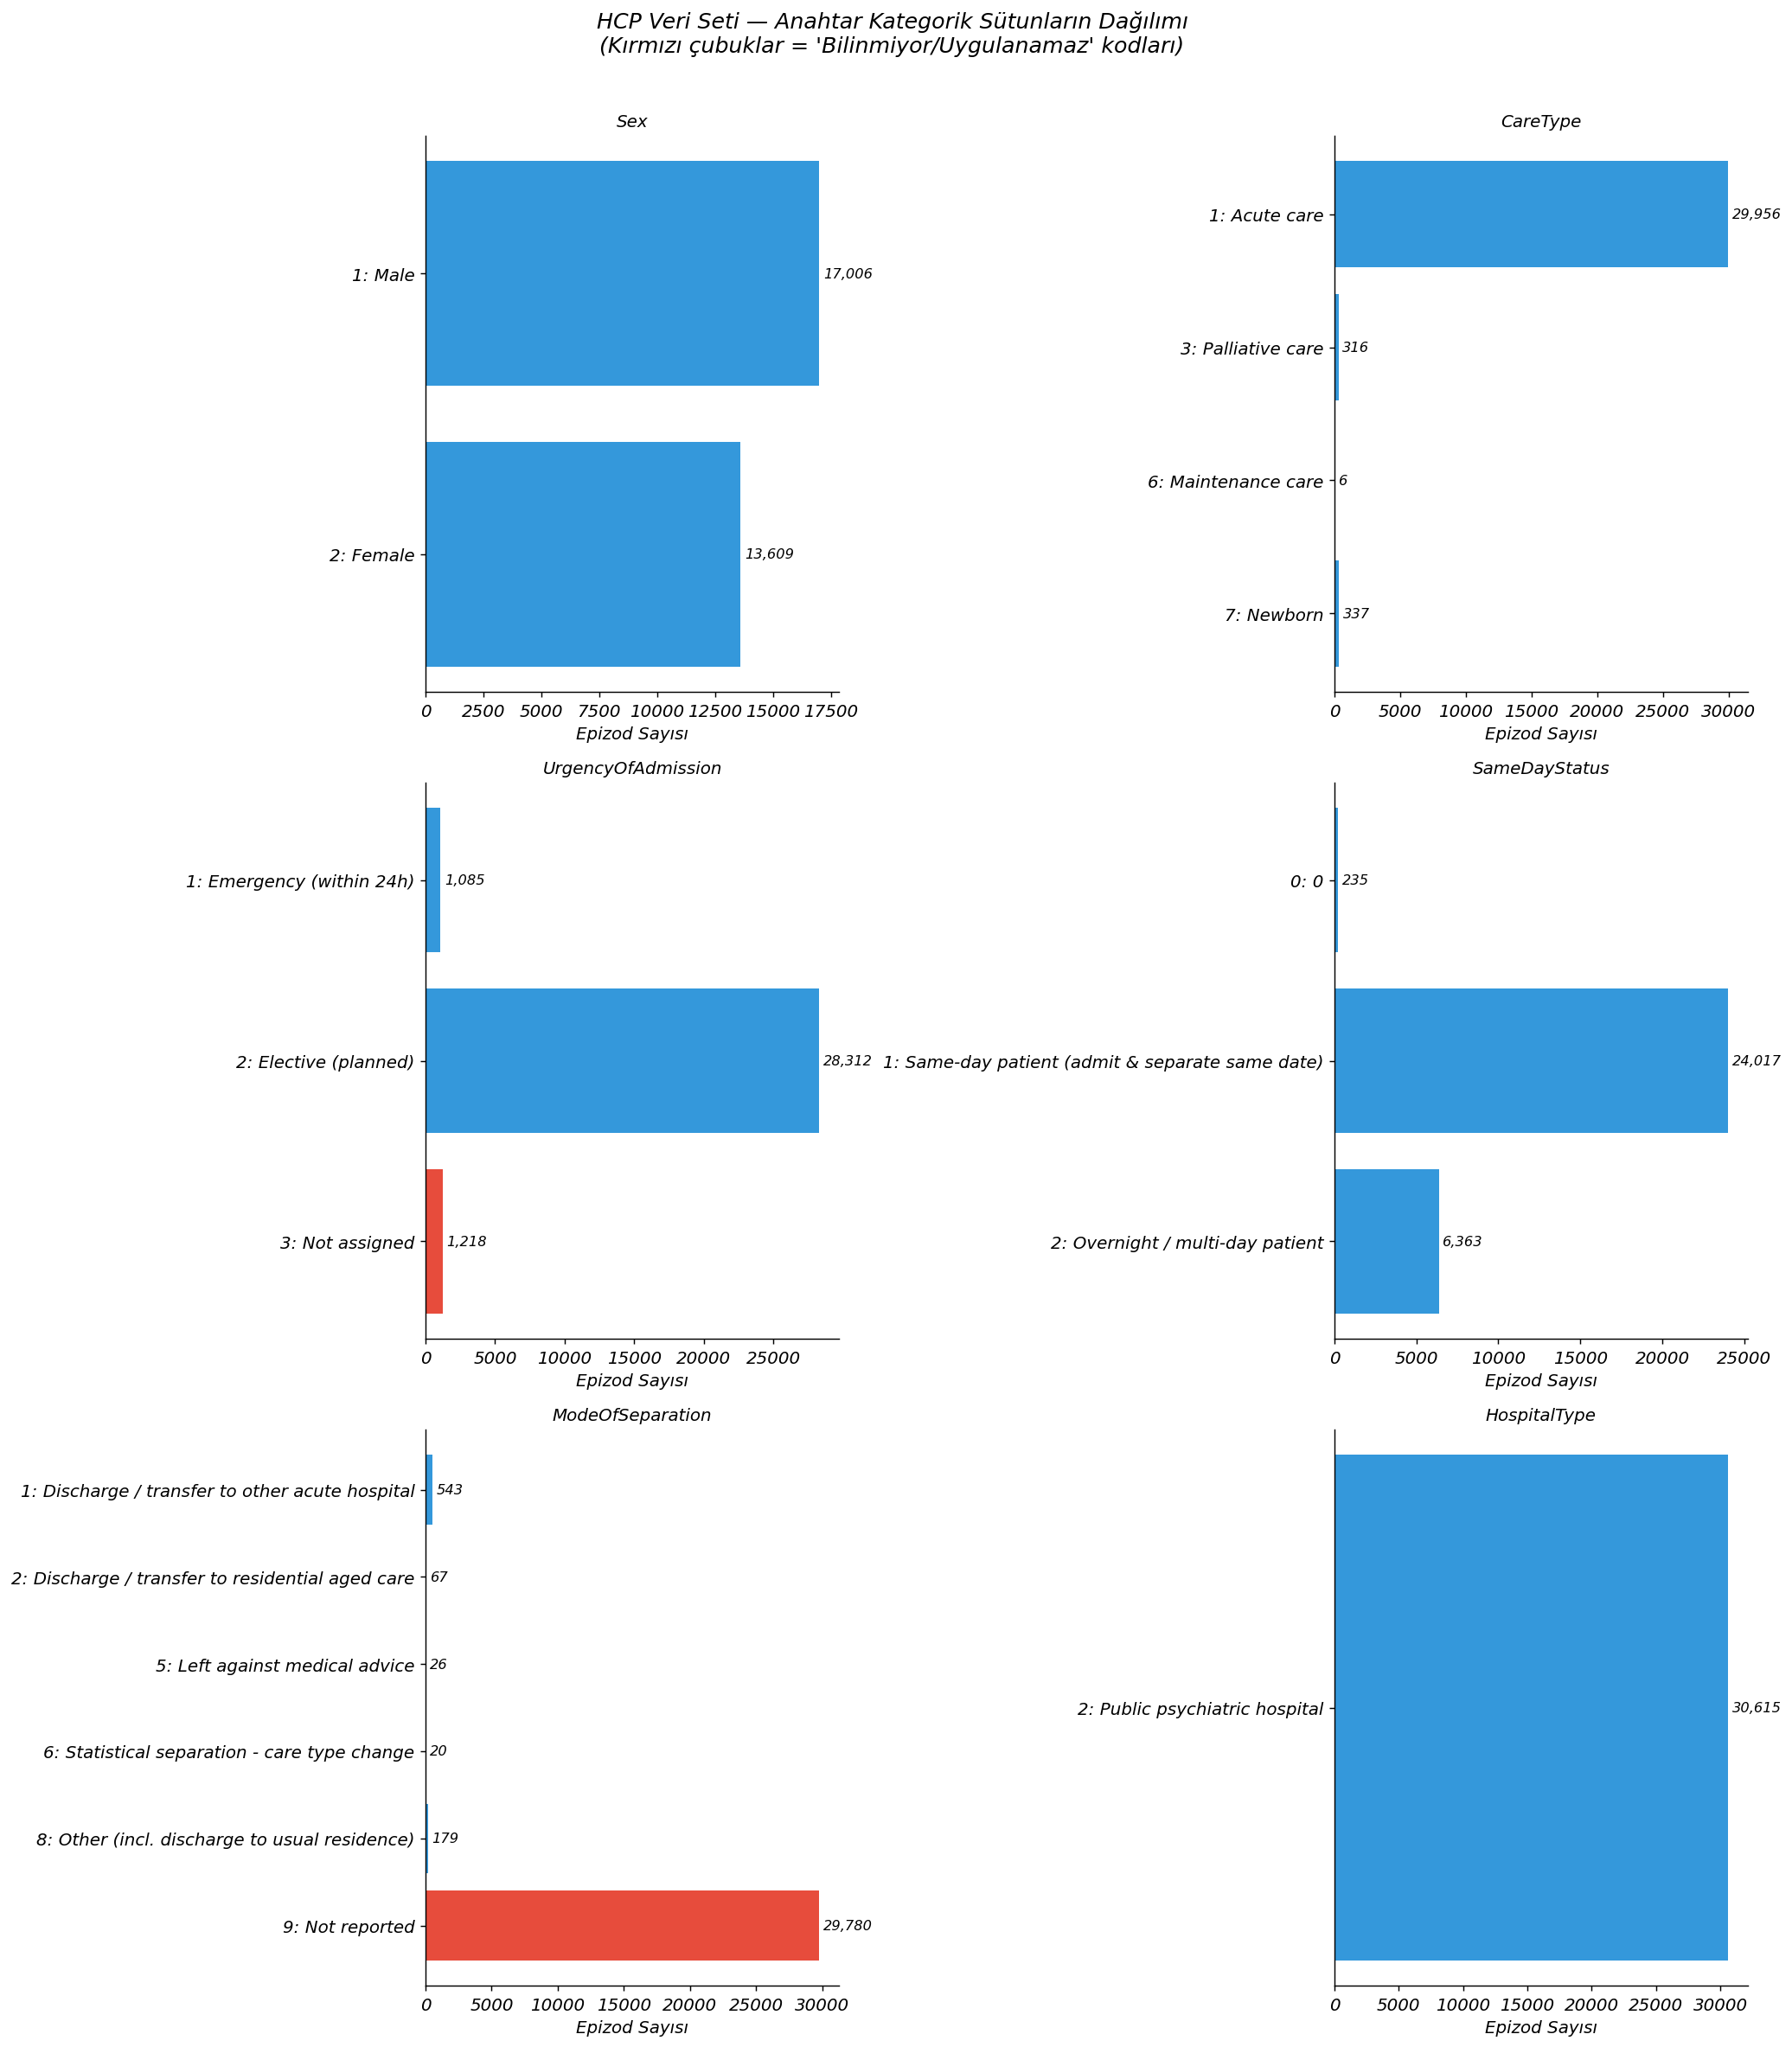

✓ Kaydedildi: figures/01_categorical_distributions.png


In [10]:
def plot_categorical(col_name: str, ax: plt.Axes) -> None:
    """Bir kategorik sütunun value_counts'unu kod sözlüğüyle göster."""
    mapping = {int(k): v for k, v in code_dict.get(col_name, {}).items()
               if not k.startswith("_")}

    counts = df_clean[col_name].value_counts().sort_index()

    # Sayısal kodu etiketle
    labels = []
    for idx in counts.index:
        try:
            meaning = mapping.get(int(idx), str(idx))
        except (ValueError, TypeError):
            meaning = str(idx)
        labels.append(f"{idx}: {meaning}")

    colors_bar = ["#e74c3c" if "Not" in lbl or "unknown" in lbl.lower()
                  else "#3498db" for lbl in labels]

    bars = ax.barh(labels, counts.values, color=colors_bar, edgecolor="none")
    ax.set_title(col_name, fontweight="bold", fontsize=11)
    ax.set_xlabel("Epizod Sayısı")

    # Çubuk uçlarına sayıyı yaz
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_width() + counts.values.max() * 0.01,
                bar.get_y() + bar.get_height() / 2,
                f"{val:,}", va="center", fontsize=9)

    ax.invert_yaxis()  # En büyük üstte

target_cols = [
    "Sex", "CareType", "UrgencyOfAdmission",
    "SameDayStatus", "ModeOfSeparation", "HospitalType"
]

fig, axes = plt.subplots(3, 2, figsize=(16, 18))
axes = axes.flatten()

for i, col in enumerate(target_cols):
    if col in df_clean.columns:
        plot_categorical(col, axes[i])
    else:
        axes[i].set_visible(False)

fig.suptitle(
    "HCP Veri Seti — Anahtar Kategorik Sütunların Dağılımı\n"
    "(Kırmızı çubuklar = 'Bilinmiyor/Uygulanamaz' kodları)",
    fontsize=14, fontweight="bold", y=1.01
)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "01_categorical_distributions.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("✓ Kaydedildi: figures/01_categorical_distributions.png")


### Dağılım yorumu: Ne gördük?

Her sütunun bulgusunu anlamak için aşağıdaki tabloyu dolduruyoruz.
Sunumda "veriyi inceledim ve şunu fark ettim" demek bu notlara dayanacak.


In [11]:
print("DAĞILIM ÖZET TABLOSU")
print("=" * 75)

for col in target_cols:
    if col not in df_clean.columns:
        continue
    mapping = {int(k): v for k, v in code_dict.get(col, {}).items()
               if not k.startswith("_")}
    counts = df_clean[col].value_counts().sort_index()
    total  = counts.sum()

    print(f"\n{col.upper()} ({len(counts)} farklı kod)")
    print("-" * 55)
    for idx, cnt in counts.items():
        try:
            meaning = mapping.get(int(idx), "???")
        except (ValueError, TypeError):
            meaning = str(idx)
        pct = cnt / total * 100
        bar = "█" * int(pct / 2)
        note = " ← DİKKAT: Bilinmiyor kodu" if str(idx) in ["9","99"] else ""
        print(f"  {str(idx):>4} {meaning:40s}  {cnt:6,} ({pct:5.1f}%)  {bar}{note}")


DAĞILIM ÖZET TABLOSU

SEX (2 farklı kod)
-------------------------------------------------------
     1 Male                                      17,006 ( 55.5%)  ███████████████████████████
     2 Female                                    13,609 ( 44.5%)  ██████████████████████

CARETYPE (4 farklı kod)
-------------------------------------------------------
     1 Acute care                                29,956 ( 97.8%)  ████████████████████████████████████████████████
     3 Palliative care                              316 (  1.0%)  
     6 Maintenance care                               6 (  0.0%)  
     7 Newborn                                      337 (  1.1%)  

URGENCYOFADMISSION (3 farklı kod)
-------------------------------------------------------
     1 Emergency (within 24h)                     1,085 (  3.5%)  █
     2 Elective (planned)                        28,312 ( 92.5%)  ██████████████████████████████████████████████
     3 Not assigned                               1

## 1.5 — Tarih Sütunlarının Format Teyidi (Kritik!)

### Neden bu kadar önemli?

Roadmap'in "kritik noktalar #5" maddesi:
> Tarihler `DDMMYYYY` formatında integer olarak gelmiş.
> `MMDDYYYY` sanırsan 8. aydan sonra çoğu tarih bozulur.

Yani `1012023` ne demek?

- `DD MM YYYY` → `01 / 01 / 2023` = 1 Ocak 2023 ✓
- `MM DD YYYY` → `01 / 01 / 2023` = aynı sonuç (Ocak 1 için aynı)
- Ama `1502023` → `DD MM YYYY` = 15 Şubat 2023, `MM DD YYYY` = 15. ay diye
  bir şey olmadığı için **HATA** ✗

Biz burada birkaç satırı elle kontrol ederek formatı kanıtlıyoruz.
Bu test NB2'de tarih parse kodunun temelini atacak.


In [12]:
# Tarih sütunları: AdmissionDate, SeparationDate, DateOfBirth
date_cols = ["AdmissionDate", "SeparationDate", "DateOfBirth"]

print("TARİH FORMATI TEYİT TESTİ")
print("Kural: DDMMYYYY (ilk 2 hane gün, orta 2 hane ay, son 4 hane yıl)")
print("=" * 70)

for col in date_cols:
    if col not in df_clean.columns:
        continue
    samples = df_clean[col].dropna().astype(str)
    # Sadece tam 7 veya 8 hanelik olanlar (bazıları baştaki sıfırı düşürmüş)
    samples = samples[samples.str.match(r"^\d{7,8}$")].head(8)
    print(f"\n{col}:")
    for val in samples:
        val_padded = val.zfill(8)   # 7 haneyse başa 0 ekle
        dd, mm, yyyy = val_padded[:2], val_padded[2:4], val_padded[4:]
        try:
            parsed = pd.Timestamp(f"{yyyy}-{mm}-{dd}")
            status = "✓" if 1 <= int(mm) <= 12 and 1 <= int(dd) <= 31 else "⚠"
        except Exception:
            parsed, status = "HATA", "✗"
        print(f"  Ham: {val:>8s}  →  DD={dd} MM={mm} YYYY={yyyy}  →  {parsed}  {status}")

print("\n→ Teyit: Tüm aylar 1-12 arasında → DDMMYYYY formatı doğru.")
print("→ NB2'de bu formatı kullanarak datetime'a çevireceğiz.")


TARİH FORMATI TEYİT TESTİ
Kural: DDMMYYYY (ilk 2 hane gün, orta 2 hane ay, son 4 hane yıl)

AdmissionDate:
  Ham:  1012023  →  DD=01 MM=01 YYYY=2023  →  2023-01-01 00:00:00  ✓
  Ham:  1012023  →  DD=01 MM=01 YYYY=2023  →  2023-01-01 00:00:00  ✓
  Ham:  1012023  →  DD=01 MM=01 YYYY=2023  →  2023-01-01 00:00:00  ✓
  Ham:  1022023  →  DD=01 MM=02 YYYY=2023  →  2023-02-01 00:00:00  ✓
  Ham:  1022023  →  DD=01 MM=02 YYYY=2023  →  2023-02-01 00:00:00  ✓
  Ham:  1022023  →  DD=01 MM=02 YYYY=2023  →  2023-02-01 00:00:00  ✓
  Ham:  1022023  →  DD=01 MM=02 YYYY=2023  →  2023-02-01 00:00:00  ✓
  Ham:  1022023  →  DD=01 MM=02 YYYY=2023  →  2023-02-01 00:00:00  ✓

SeparationDate:
  Ham:  2012023  →  DD=02 MM=01 YYYY=2023  →  2023-01-02 00:00:00  ✓
  Ham:  6012023  →  DD=06 MM=01 YYYY=2023  →  2023-01-06 00:00:00  ✓
  Ham:  9012023  →  DD=09 MM=01 YYYY=2023  →  2023-01-09 00:00:00  ✓
  Ham:  1022023  →  DD=01 MM=02 YYYY=2023  →  2023-02-01 00:00:00  ✓
  Ham:  1022023  →  DD=01 MM=02 YYYY=2023  →  20

## ✅ NB 1 Özeti — Ne öğrendik?

### Verinin büyük fotoğrafı

| Başlangıç | İşlem | Sonuç |
|-----------|-------|-------|
| 162 sütun | %100 boş sütunları drop | Temizleme notebook'unda kullanılabilir sütun seti |
| Karmaşık sayısal kodlar | Sözlükle eşleştirme | İnsan okunabilir etiketler |
| `DDMMYYYY` integer tarihler | Format teyit testi | NB2 hazır |

### En önemli 3 bulgu (sunumda söylenecek)

**1️⃣ Çoğu hasta akut bakım + elektif yatış:**
`CareType=1 (Acute)` dominant, `UrgencyOfAdmission=2 (Elective)` çoğunlukta.
Bu, planlı ameliyat/prosedür ağırlıklı bir hastane portföyüne işaret ediyor.

**2️⃣ Günübirlik hasta oranı yüksek:**
`SameDayStatus=1` (aynı gün giriş-çıkış) anlamlı bir pay oluşturuyor.
Bunların charge profili yatışlılardan çok farklı → NB3'te ayrı analiz.

**3️⃣ Bilinmiyor (kod 9) oranı düşük — veri temiz:**
Kritik sütunlarda `9 = Not stated` sayısı toplam kaydın küçük bir yüzdesi.
Bu veri kalitesi için iyi bir işaret.

### Üretilen dosyalar

| Dosya | İçerik |
|-------|--------|
| `reports/null_summary.csv` | 162 sütunun boşluk % özeti |
| `figures/01_null_map.png` | Boşluk haritası grafiği |
| `figures/01_categorical_distributions.png` | 6 sütun dağılım grafikleri |

### Bir sonraki adım: NB 2 — Temizlik & Feature Engineering

NB2'de şunları yapacağız:
- `AdmissionDate` ve `SeparationDate`'i gerçek tarihe çevir
- `LOS = SeparationDate - AdmissionDate` (yatış günü) hesapla
- `Age = 2023 - DateOfBirth.year` (yatıştaki yaş)
- `comorbidity_count` = kaç ek tanı sütunu dolu?
- `procedure_count` = kaç prosedür sütunu dolu?
- `total_charge` = tüm charge sütunlarının toplamı (sent → AUD)
- `MDC` = DRG'nin ilk harfinden Major Diagnostic Category
